### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")
device = torch.device("cuda" if cuda_available else "cpu")
print(f"Using device: {device}")


PyTorch version: 2.10.0+cu126
CUDA available: True
Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
cd Your_Dir/emg2qwerty

### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [4]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  # --multirun

LexerNoViableAltException: #
                           ^
See https://hydra.cc/docs/1.2/advanced/override_grammar/basic for details


Set the environment variable HYDRA_FULL_ERROR=1 for a complete stack trace.


In [3]:
!python -m emg2qwerty.train user="single_user" trainer.accelerator=gpu trainer.devices=1


[2026-03-09 01:27:19,981][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: c:\Users\yukat\emg2qwerty\logs\2026-03-09\01-27-19\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\yukat\miniconda3\envs\emg2qwerty\lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\yukat\miniconda3\envs\emg2qwerty\lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\yukat\miniconda3\envs\emg2qwerty\lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and 


Epoch 97:  94%|█████████▍| 120/127 [00:19<00:01,  6.02it/s, loss=0.197, v_num=0]

Validation: 0it [00:00, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 97:  95%|█████████▌| 121/127 [00:20<00:01,  5.90it/s, loss=0.197, v_num=0]

Epoch 97:  96%|█████████▌| 122/127 [00:20<00:00,  5.93it/s, loss=0.197, v_num=0]

Epoch 97:  97%|█████████▋| 123/127 [00:20<00:00,  5.96it/s, loss=0.197, v_num=0]

Epoch 97:  98%|█████████▊| 124/127 [00:20<00:00,  5.99it/s, loss=0.197, v_num=0]

Epoch 97:  98%|█████████▊| 125/127 [00:20<00:00,  6.00it/s, loss=0.197, v_num=0]

Epoch 97:  99%|█████████▉| 126/127 [00:20<00:00,  6.03it/s, loss=0.197, v_num=0]

Epoch 97: 100%|██████████| 127/127 [00:20<00:00,  6.07it/s, loss=0.197, v_num=0]

                                                                      
Epoch 98:  94%|█████████▍| 120/127 [00:19<00:01,  6.02it/s, loss=0.207, v_num=0]

Validation: 0it [00:00, ?it/s]

Validation:

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [4]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="C:\Users\yukat\emg2qwerty\logs\2026-03-09\01-27-19\checkpoints\epoch=113-step=13680.ckpt" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

^C


mismatched input '=' expecting <EOF>
See https://hydra.cc/docs/1.2/advanced/override_grammar/basic for details


Set the environment variable HYDRA_FULL_ERROR=1 for a complete stack trace.


In [3]:
!python -m emg2qwerty.train \
  user="single_user" \
  "checkpoint='c:/Users/yukat/emg2qwerty/logs/2026-03-09/01-27-19/checkpoints/epoch=113-step=13680.ckpt'" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy

[2026-03-09 02:51:09,723][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: c:\Users\yukat\emg2qwerty\logs\2026-03-09\02-51-09\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


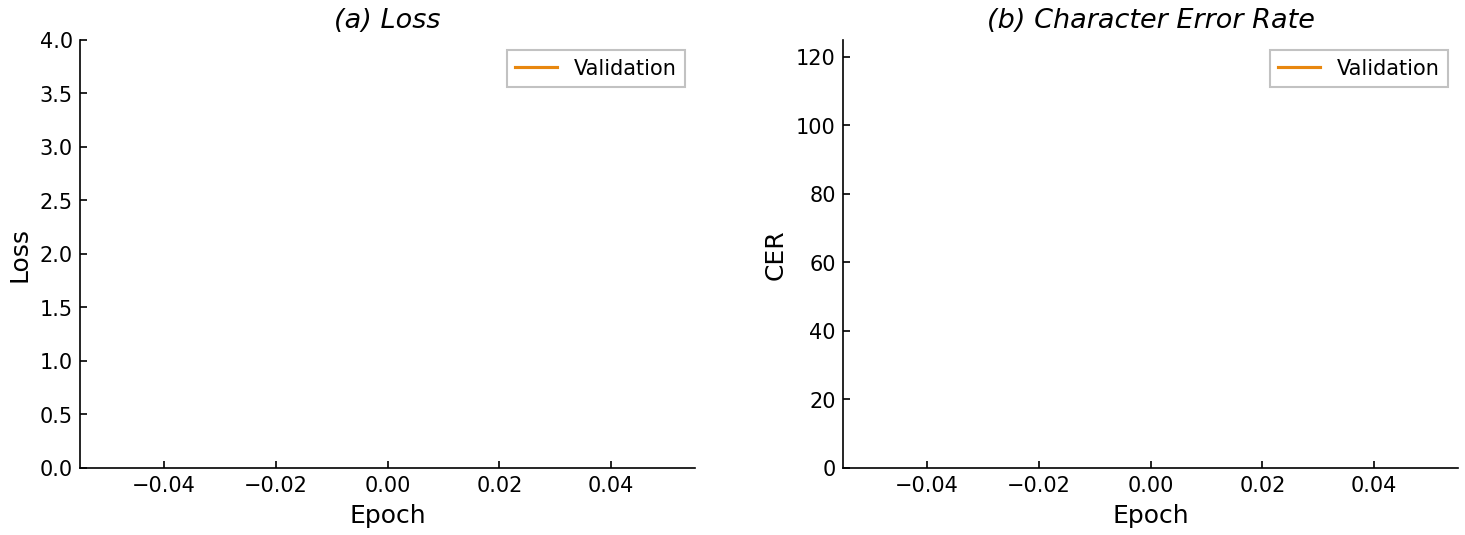

Saved to figures/training_progress.png and .pdf


In [13]:
"""Plot training progress from TensorBoard logs."""

import os
import matplotlib
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOG_DIR = "C:/Users/yukat/emg2qwerty/logs/2026-03-09/06-19-42/lightning_logs/version_0"

ea = EventAccumulator(LOG_DIR)
ea.Reload()

def get_scalars(tag):
    events = ea.Scalars(tag)
    return [(e.step, e.value) for e in events]

# Build step -> epoch mapping
epoch_events = get_scalars("epoch")
step_to_epoch = {step: val for step, val in epoch_events}
epoch_steps_sorted = sorted(step_to_epoch)

def ffill_epoch(step):
    """Return the most recent epoch value at or before this step."""
    for s in reversed(epoch_steps_sorted):
        if s <= step:
            return step_to_epoch[s]
    return None

def get_epoch_series(tag):
    """Returns (epoch_list, mean_value_list) grouped by epoch."""
    bucket = {}
    for step, val in get_scalars(tag):
        epoch = ffill_epoch(step)
        if epoch is not None:
            bucket.setdefault(epoch, []).append(val)
    epochs = sorted(bucket)
    means = [sum(bucket[e]) / len(bucket[e]) for e in epochs]
    return epochs, means

# --- Research paper style ---
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

TRAIN_COLOR = "#7b2d8e"
VAL_COLOR   = "#e8870e"
available   = ea.Tags()["scalars"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

# --- (a) Loss vs Epoch ---
for tag, label, color in [("train/loss_epoch", "Train", TRAIN_COLOR), ("val/loss", "Validation", VAL_COLOR)]:
    if tag in available:
        x, y = get_epoch_series(tag)
        ax1.plot(x, y, label=label, color=color)
ax1.set_ylim(0, 4); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("(a) Loss", style="italic")
ax1.legend(frameon=True, fancybox=False, edgecolor="0.7")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.tick_params(direction="in")

# --- (b) CER vs Epoch ---
for tag, label, color in [("train/CER", "Train", TRAIN_COLOR), ("val/CER", "Validation", VAL_COLOR)]:
    if tag in available:
        x, y = get_epoch_series(tag)
        ax2.plot(x, y, label=label, color=color)
ax2.set_ylim(0, 125); ax2.set_xlabel("Epoch"); ax2.set_ylabel("CER")
ax2.set_title("(b) Character Error Rate", style="italic")
ax2.legend(frameon=True, fancybox=False, edgecolor="0.7")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.tick_params(direction="in")

plt.tight_layout(w_pad=3.0)
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/training_progress.png")
plt.savefig("figures/training_progress.pdf")
plt.show()
print("Saved to figures/training_progress.png and .pdf")


In [14]:
ea = EventAccumulator(LOG_DIR)
ea.Reload()
print(ea.Tags()["scalars"])

['hp_metric', 'val/loss', 'val/CER', 'val/IER', 'val/DER', 'val/SER', 'epoch', 'test/loss', 'test/CER', 'test/IER', 'test/DER', 'test/SER']


In [15]:
# Find which runs have training data
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob

for d in sorted(glob.glob("logs/*/*/lightning_logs/version_0")):
    ea = EventAccumulator(d)
    ea.Reload()
    tags = ea.Tags()["scalars"]
    has_train = any("train" in t for t in tags)
    n_epochs = len(ea.Scalars("epoch")) if "epoch" in tags else 0
    print(f"{d}  train={has_train}  epochs={n_epochs}  tags={tags}")

logs\2026-03-08\04-31-02\lightning_logs\version_0  train=False  epochs=0  tags=['hp_metric']
logs\2026-03-08\04-42-36\lightning_logs\version_0  train=False  epochs=0  tags=['hp_metric']
logs\2026-03-08\04-43-05\lightning_logs\version_0  train=False  epochs=0  tags=['hp_metric']
logs\2026-03-08\04-45-16\lightning_logs\version_0  train=False  epochs=0  tags=['hp_metric']
logs\2026-03-09\01-14-27\lightning_logs\version_0  train=False  epochs=0  tags=['hp_metric']
logs\2026-03-09\01-25-56\lightning_logs\version_0  train=False  epochs=0  tags=['hp_metric']
logs\2026-03-09\01-27-19\lightning_logs\version_0  train=True  epochs=660  tags=['hp_metric', 'lr-Adam', 'train/loss', 'epoch', 'val/loss', 'val/CER', 'val/IER', 'val/DER', 'val/SER', 'train/CER', 'train/IER', 'train/DER', 'train/SER']
logs\2026-03-09\02-51-09\lightning_logs\version_0  train=False  epochs=2  tags=['hp_metric', 'val/loss', 'val/CER', 'val/IER', 'val/DER', 'val/SER', 'epoch', 'test/loss', 'test/CER', 'test/IER', 'test/DER',

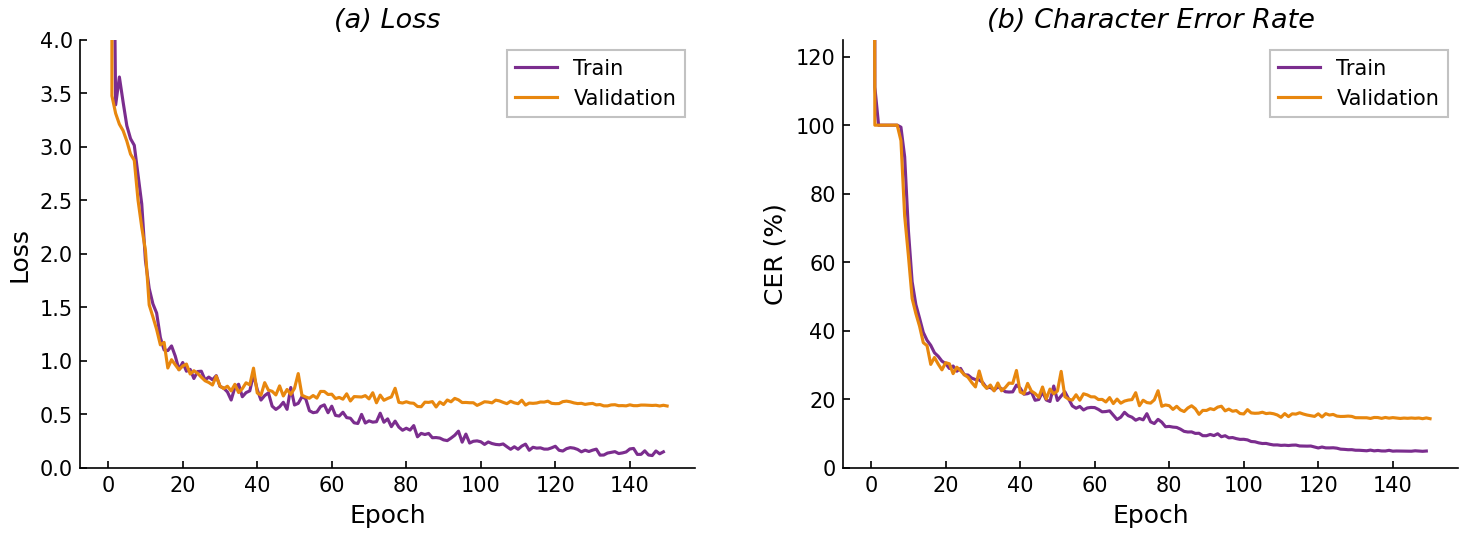

Saved to figures/training_progress.png and .pdf


In [19]:
"""Plot training progress from the main training run."""

import os
import matplotlib
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOG_DIR = "logs/2026-03-09/03-06-27/lightning_logs/version_0"

ea = EventAccumulator(LOG_DIR)
ea.Reload()
available = ea.Tags()["scalars"]

def get_scalars(tag):
    return [(e.step, e.value) for e in ea.Scalars(tag)]

# Build step -> epoch mapping
epoch_events = get_scalars("epoch")
step_to_epoch = {step: val for step, val in epoch_events}
epoch_steps_sorted = sorted(step_to_epoch)

def ffill_epoch(step):
    for s in reversed(epoch_steps_sorted):
        if s <= step:
            return step_to_epoch[s]
    return None

def get_epoch_series(tag):
    bucket = {}
    for step, val in get_scalars(tag):
        epoch = ffill_epoch(step)
        if epoch is not None:
            bucket.setdefault(epoch, []).append(val)
    epochs = sorted(bucket)
    means = [sum(bucket[e]) / len(bucket[e]) for e in epochs]
    return epochs, means

# --- Research paper style ---
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

TRAIN_COLOR = "#7b2d8e"
VAL_COLOR   = "#e8870e"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

# --- (a) Loss vs Epoch ---
for tag, label, color in [("train/loss", "Train", TRAIN_COLOR), ("val/loss", "Validation", VAL_COLOR)]:
    if tag in available:
        x, y = get_epoch_series(tag)
        ax1.plot(x, y, label=label, color=color)
ax1.set_ylim(bottom=0)
ax1.set_ylim(0, 4)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("(a) Loss", style="italic")
ax1.legend(frameon=True, fancybox=False, edgecolor="0.7")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.tick_params(direction="in")

# --- (b) CER vs Epoch ---
for tag, label, color in [("train/CER", "Train", TRAIN_COLOR), ("val/CER", "Validation", VAL_COLOR)]:
    if tag in available:
        x, y = get_epoch_series(tag)
        ax2.plot(x, y, label=label, color=color)
ax2.set_ylim(bottom=0)
ax2.set_ylim(0, 125)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("CER (%)")
ax2.set_title("(b) Character Error Rate", style="italic")
ax2.legend(frameon=True, fancybox=False, edgecolor="0.7")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.tick_params(direction="in")

plt.tight_layout(w_pad=3.0)
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/training_progress.png")
plt.savefig("figures/training_progress.pdf")
plt.show()
print("Saved to figures/training_progress.png and .pdf")

In [17]:
with open("logs/2026-03-09/03-06-27/emg2qwerty.log") as f:
    print(f.read())


[2026-03-09 03:06:27,452][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [18]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator("logs/2026-03-09/03-06-27/lightning_logs/version_0")
ea.Reload()

# Build epoch -> metrics table
epoch_events = {step: val for step, val in [(e.step, e.value) for e in ea.Scalars("epoch")]}
epoch_steps = sorted(epoch_events)

def get_at_epochs(tag):
    return {epoch_events[e.step]: e.value for e in ea.Scalars(tag) if e.step in epoch_events}

metrics = ["val/loss", "val/CER", "train/loss", "train/CER"]
data = {m: get_at_epochs(m) for m in metrics if m in ea.Tags()["scalars"]}
all_epochs = sorted(set(e for d in data.values() for e in d))

print(f"{'Epoch':>6}  {'train/loss':>10}  {'val/loss':>10}  {'train/CER':>10}  {'val/CER':>10}")
for ep in all_epochs:
    row = [data[m].get(ep, float('nan')) for m in metrics]
    print(f"{int(ep):>6}  {row[2]:>10.4f}  {row[0]:>10.4f}  {row[3]:>10.2f}  {row[1]:>10.2f}")


 Epoch  train/loss    val/loss   train/CER     val/CER
     0    148.9567    141.0017     1157.17      568.79
     1      3.5270      3.4738      111.10      100.00
     2      3.4393      3.3099      100.00      100.00
     3      3.5544      3.2092      100.00      100.00
     4      3.2495      3.1490      100.00      100.00
     5      3.2107      3.0518      100.00      100.00
     6      3.0763      2.9297      100.00      100.00
     7      2.8784      2.8716      100.00      100.00
     8      2.6757      2.5020       99.42       95.48
     9      2.2471      2.2476       90.76       73.48
    10      1.8673      2.0291       69.32       61.92
    11      1.7060      1.5219       54.35       49.45
    12      1.4117      1.4101       47.67       45.04
    13      1.2866      1.2924       43.67       41.32
    14      1.2242      1.1487       39.53       36.53
    15      1.1242      1.1719       37.25       35.67
    16      1.0972      0.9326       35.76       30.19
    17    